In [1]:
## imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import pmdarima as pm  # auto_arima

from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

### 1 - Pré-processamento

In [2]:
# carregando arquivos
ipca = pd.read_csv('ipca.csv', parse_dates=['data'], index_col='data')
cpi  = pd.read_csv('us_cpi.csv', parse_dates=['date'], index_col='date')
fx   = pd.read_csv('usd_brl_monthly.csv', parse_dates=['data'], index_col='data')

In [3]:
# frequência mensal
ipca = ipca.asfreq('MS')  # 'MS' = início do mês
cpi  = cpi.asfreq('MS')
fx   = fx.asfreq('MS')

In [9]:
# Seleciona apenas date + coluna do número antes do merge
cpi_clean = cpi[['value']].rename(columns={'value': 'us_cpi'})
ipca_clean = ipca[['valor']].rename(columns={'valor': 'ipca'})
fx_clean = fx[['valor_ultimo_mes']].rename(columns={'valor_ultimo_mes': 'usd_brl'})

In [10]:
df = ipca_clean.join(cpi_clean, how='left').join(fx_clean, how='left')

In [11]:
df.head()

,ipca,us_cpi,usd_brl
data,,,
2000-01-01,0.62,168.8,1.8024
2000-02-01,0.13,169.8,1.7685
2000-03-01,0.22,171.2,1.7473
2000-04-01,0.42,171.3,1.8067
2000-05-01,0.01,171.5,1.8266


In [8]:
print(df.isnull().sum())
print(f"\nPeríodo: {df.index.min()} → {df.index.max()}")
print(f"Total de observações: {len(df)}")

br_ipca    0
us_cpi     0
br_fx      0
dtype: int64

Período: 2000-01-01 00:00:00 → 2024-12-01 00:00:00
Total de observações: 300


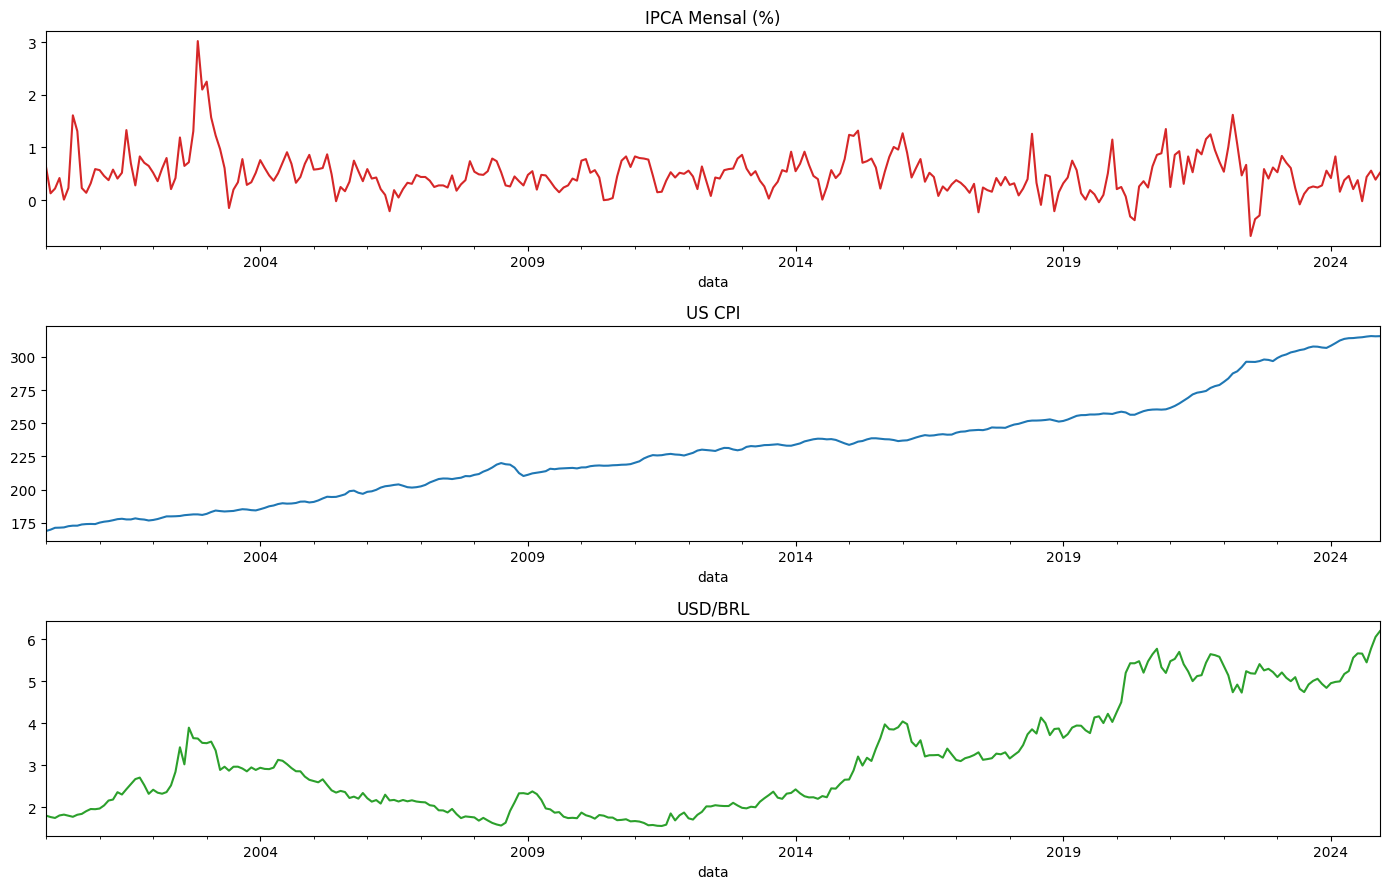

             ipca    us_cpi   usd_brl
ipca     1.000000 -0.145794  0.051054
us_cpi  -0.145794  1.000000  0.760866
usd_brl  0.051054  0.760866  1.000000


In [ ]:
# análise exploratória
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
df['ipca'].plot(ax=axes[0], title='IPCA Mensal (%)', color='tab:red')
df['us_cpi'].plot(ax=axes[1], title='US CPI', color='tab:blue')
df['usd_brl'].plot(ax=axes[2], title='USD/BRL', color='tab:green')
plt.tight_layout()
plt.show()

# Correlações
print(df.corr())

### 2 - Análise de estacionariedade (ADF)

In [14]:
def adf_test(series, name=''):
    result = adfuller(series.dropna())
    print(f"\n{'='*40}")
    print(f"ADF Test — {name}")
    print(f"  Estatística: {result[0]:.4f}")
    print(f"  p-valor:     {result[1]:.4f}")
    print(f"  {'✅ Estacionária' if result[1] < 0.05 else '❌ NÃO estacionária (diferenciar)'}")

for col in df.columns:
    adf_test(df[col], col)


ADF Test — ipca
  Estatística: -8.3602
  p-valor:     0.0000
  ✅ Estacionária

ADF Test — us_cpi
  Estatística: 1.0285
  p-valor:     0.9946
  ❌ NÃO estacionária (diferenciar)

ADF Test — usd_brl
  Estatística: -0.1267
  p-valor:     0.9467
  ❌ NÃO estacionária (diferenciar)


In [15]:
# Diferencia as exógenas não estacionárias
df['us_cpi_diff'] = df['us_cpi'].diff()
df['usd_brl_diff'] = df['usd_brl'].diff()

# Remove o NaN gerado pela diferenciação (primeira linha)
df.dropna(inplace=True)

# Confirma que ficaram estacionárias
adf_test(df['us_cpi_diff'], 'us_cpi_diff')
adf_test(df['usd_brl_diff'], 'usd_brl_diff')


ADF Test — us_cpi_diff
  Estatística: -2.8416
  p-valor:     0.0526
  ❌ NÃO estacionária (diferenciar)

ADF Test — usd_brl_diff
  Estatística: -10.8534
  p-valor:     0.0000
  ✅ Estacionária


In [16]:
# p-valor de 0.0526 é borderline — muitos trabalhos acadêmicos aceitam
# Reforce com o teste KPSS para ter uma segunda opinião
from statsmodels.tsa.stattools import kpss

stat, p_val, lags, crit = kpss(df['us_cpi_diff'].dropna(), regression='c')
print(f"KPSS p-valor: {p_val:.4f}")
# Se p-valor > 0.05 no KPSS → confirma estacionariedade (os dois testes concordam)

KPSS p-valor: 0.0450


In [17]:
# como KPSS deu p-valoe < 0.05, vamos diferenciar mais uma vez
df['us_cpi_diff2'] = df['us_cpi'].diff().diff()
df.dropna(inplace=True)

adf_test(df['us_cpi_diff2'], 'us_cpi_diff2')

stat, p_val, lags, crit = kpss(df['us_cpi_diff2'].dropna(), regression='c')
print(f"KPSS p-valor: {p_val:.4f}")


ADF Test — us_cpi_diff2
  Estatística: -11.0191
  p-valor:     0.0000
  ✅ Estacionária
KPSS p-valor: 0.1000


### 3 - Seleção de ordem (ACF/PACF + AIC)

# documentar que o CPI americano é I(2) — ou seja, precisou de duas diferenciações para estacionarizar. Isso tem interpretação econômica: sugere que não só o nível, mas a própria variação do CPI americano tem tendência, o que é consistente com períodos de inflação persistente nos EUA (como 2021-2023 na amostra utilizada).

# ipca - nenhuma transformação - I(0)
# us_cpi - .diff().diff() - I(2)
# usd_brl - .diff() i I(1)

In [20]:
exog_cols = ['us_cpi_diff2', 'usd_brl_diff']

auto_model = pm.auto_arima(
    df['ipca'],
    exogenous=df[exog_cols],
    start_p=0, max_p=4,
    start_q=0, max_q=4,
    d=0,
    seasonal=False,
    information_criterion='aic',
    stepwise=True,
    trace=True
)

print(auto_model.summary())
print(f"\nMelhor ordem ARIMA: {auto_model.order}")

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=579.434, Time=0.46 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=193.049, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=378.250, Time=0.08 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=191.070, Time=0.05 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=185.927, Time=0.07 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=186.702, Time=0.08 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=inf, Time=0.46 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.42 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=188.235, Time=0.18 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=156.939, Time=0.09 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=155.524, Time=0.06 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=153.581, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=295.471, Time=0.05 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=155.514, Time=0.16 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=189.138, Time

# ARIMA(1,0,0) com intercepto, ou seja, um AR(1) — o IPCA do mês é explicado pelo IPCA do mês anterior mais as variáveis exógenas. AIC de 153.58, bem melhor que o modelo sem intercepto.

### 4 - Treino ARIMAX → Previsão → Avaliação

In [21]:
# Últimos 12 meses como teste
train = df.iloc[:-12]
test  = df.iloc[-12:]

exog_cols = ['us_cpi_diff2', 'usd_brl_diff']

model = SARIMAX(
    train['ipca'],
    exog=train[exog_cols],
    order=(1, 0, 0),
    trend='c'  # inclui intercepto, conforme o auto_arima escolheu
)

results = model.fit(disp=False)
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                   ipca   No. Observations:                  285
Model:               SARIMAX(1, 0, 0)   Log Likelihood                 -72.213
Date:                Sat, 14 Mar 2026   AIC                            154.427
Time:                        10:39:45   BIC                            172.689
Sample:                    04-01-2000   HQIC                           161.748
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept        0.1880      0.035      5.438      0.000       0.120       0.256
us_cpi_diff2    -0.0020      0.014     -0.143      0.887      -0.030       0.026
usd_brl_diff     0.0577      0.082      0.70

# coisas boas:
# AR(1) = 0.63 com p-valor 0.000 — o IPCA do mês anterior é um preditor forte e significativo
# Ljung-Box p=0.64 — resíduos sem autocorrelação, modelo bem especificado
# Heteroskedasticidade p=0.67 — variância dos resíduos estável

# alerta:
# us_cpi_diff2 e usd_brl_diff não são significativas (p=0.887 e p=0.484) - exógenas não estão contribuindo
# Jarque-Bera p=0.00 com curtose 10.17 — resíduos não são normais, há caudas pesadas (eventos extremos como 2003, 2015, COVID)

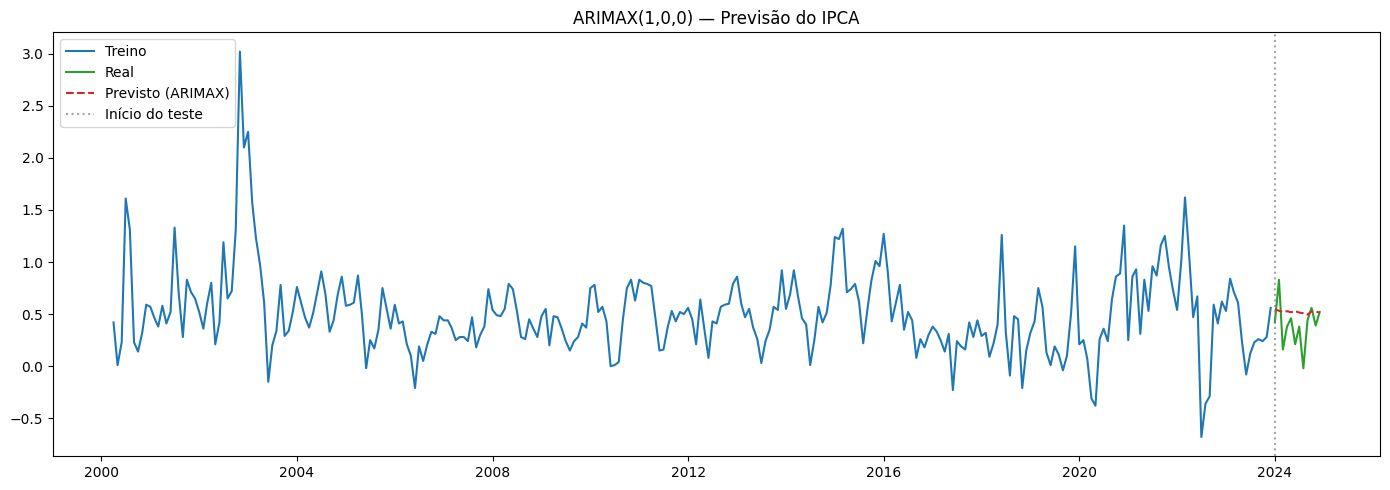

RMSE: 0.2385
MAE:  0.1836


In [22]:
forecast = results.forecast(steps=12, exog=test[exog_cols])

plt.figure(figsize=(14, 5))
plt.plot(train['ipca'], label='Treino', color='tab:blue')
plt.plot(test['ipca'],  label='Real',   color='tab:green')
plt.plot(forecast,      label='Previsto (ARIMAX)', color='tab:red', linestyle='--')
plt.axvline(test.index[0], color='gray', linestyle=':', alpha=0.7, label='Início do teste')
plt.legend()
plt.title('ARIMAX(1,0,0) — Previsão do IPCA')
plt.tight_layout()
plt.show()

# Métricas
rmse = np.sqrt(mean_squared_error(test['ipca'], forecast))
mae  = mean_absolute_error(test['ipca'], forecast)
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

In [24]:
# Testando lags (defasagem) com janela de até 3 meses
df['usd_brl_diff_lag1'] = df['usd_brl_diff'].shift(1)
df['usd_brl_diff_lag2'] = df['usd_brl_diff'].shift(2)
df['usd_brl_diff_lag3'] = df['usd_brl_diff'].shift(3)

df['us_cpi_diff2_lag1'] = df['us_cpi_diff2'].shift(1)
df['us_cpi_diff2_lag2'] = df['us_cpi_diff2'].shift(2)
df['us_cpi_diff2_lag3'] = df['us_cpi_diff2'].shift(3)

df.dropna(inplace=True)

train = df.iloc[:-12]
test  = df.iloc[-12:]

exog_cols_3lag = [
    'us_cpi_diff2_lag1', 'us_cpi_diff2_lag2', 'us_cpi_diff2_lag3',
    'usd_brl_diff_lag1', 'usd_brl_diff_lag2', 'usd_brl_diff_lag3'
]

model_3lag = SARIMAX(
    train['ipca'],
    exog=train[exog_cols_3lag],
    order=(1, 0, 0),
    trend='c'
)

results_3lag = model_3lag.fit(disp=False)
print(results_3lag.summary())

forecast = results_3lag.forecast(steps=12, exog=test[exog_cols_3lag])
rmse = np.sqrt(mean_squared_error(test['ipca'], forecast))
mae  = mean_absolute_error(test['ipca'], forecast)
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

                               SARIMAX Results                                
Dep. Variable:                   ipca   No. Observations:                  280
Model:               SARIMAX(1, 0, 0)   Log Likelihood                 -45.834
Date:                Sat, 14 Mar 2026   AIC                            109.668
Time:                        10:50:45   BIC                            142.381
Sample:                    09-01-2000   HQIC                           122.789
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
intercept             0.1614      0.033      4.821      0.000       0.096       0.227
us_cpi_diff2_lag1     0.0479      0.027      1.776      0.076      -0.005       0.101
us_cpi_diff2_lag2     0.

# AR(1) = 0.68 p=0.000 — persistência inflacionária forte ✅
# usd_brl_diff_lag3 = -0.30 p=0.001 — significativo ✅ — desvalorização cambial de 3 meses atrás tem efeito negativo sobre o IPCA (pode indicar reversão ou efeito de antecipação do mercado)
# us_cpi_diff2_lag1 p=0.076 — borderline, vou manter pela teoria
# Demais lags não significativos

# nota para o TCC: o sinal negativo do usd_brl_diff_lag3 é interessante e merece discussão. Uma interpretação possível é que o Banco Central reage a desvalorizações cambiais com aperto monetário, o que contém a inflação com defasagem de 3 meses — conecta bem com a literatura sobre o regime de metas de inflação no Brasil.

In [25]:
# modelo final somente com os lags que foram significativos
exog_cols_final = ['us_cpi_diff2_lag1', 'usd_brl_diff_lag3']

train = df.iloc[:-12]
test  = df.iloc[-12:]

model_final = SARIMAX(
    train['ipca'],
    exog=train[exog_cols_final],
    order=(1, 0, 0),
    trend='c'
)

results_final = model_final.fit(disp=False)
print(results_final.summary())

forecast = results_final.forecast(steps=12, exog=test[exog_cols_final])

rmse = np.sqrt(mean_squared_error(test['ipca'], forecast))
mae  = mean_absolute_error(test['ipca'], forecast)
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

                               SARIMAX Results                                
Dep. Variable:                   ipca   No. Observations:                  280
Model:               SARIMAX(1, 0, 0)   Log Likelihood                 -48.490
Date:                Sat, 14 Mar 2026   AIC                            106.980
Time:                        10:54:46   BIC                            125.154
Sample:                    09-01-2000   HQIC                           114.270
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
intercept             0.1609      0.033      4.922      0.000       0.097       0.225
us_cpi_diff2_lag1     0.0451      0.022      2.059      0.039       0.002       0.088
usd_brl_diff_lag3    -0.

In [ ]:
# O MAE piorou levemente vs. o modelo com 6 lags, mas o AIC é menor e o modelo tem menos parâmetros — parcimônia vence.

In [ ]:
# us_cpi_diff2_lag1+0.0450.039Inflação americana eleva IPCA com 1 mês de defasagem
# usd_brl_diff_lag3-0.3880.000Pass-through cambial invertido com 3 meses

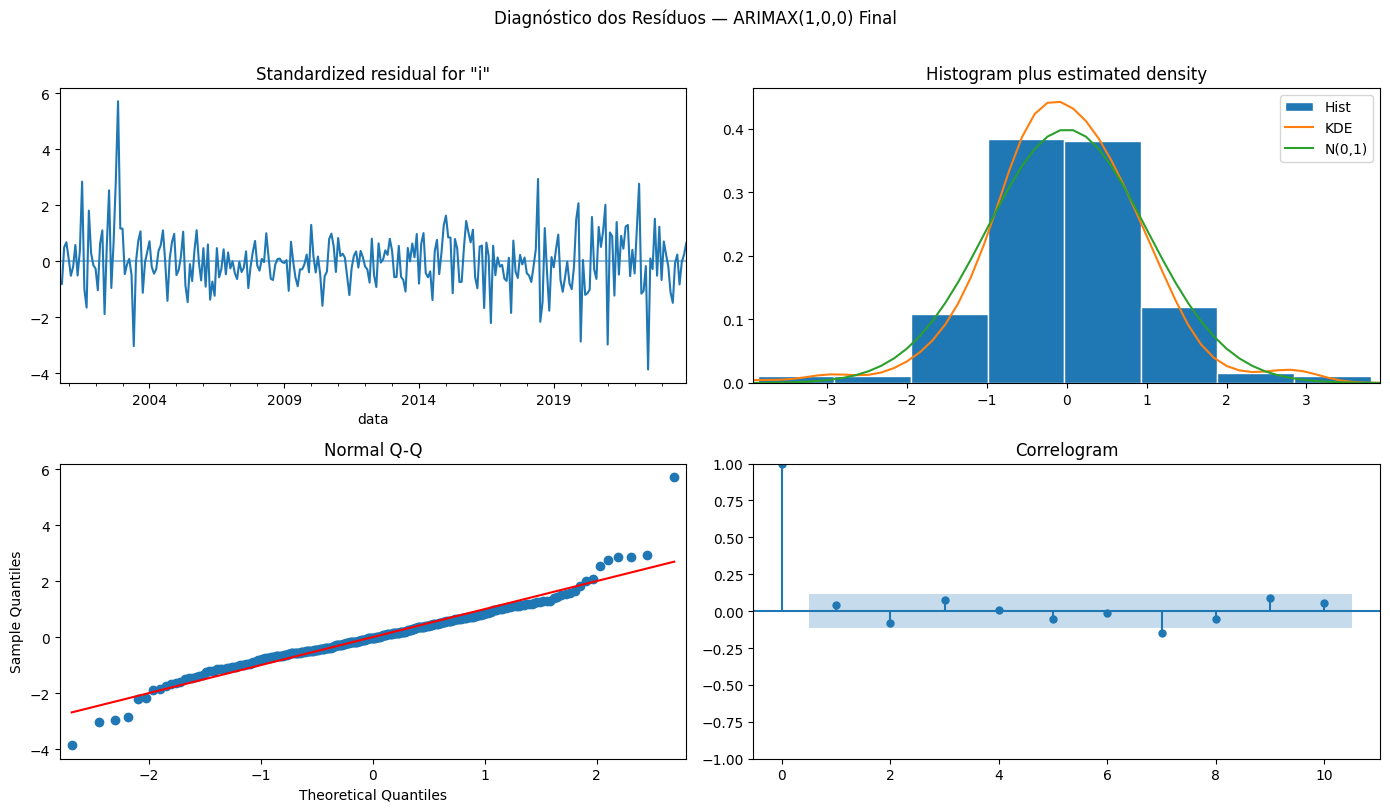

      lb_stat  lb_pvalue
6    5.125247   0.527853
12  20.417828   0.059583
24  27.324455   0.289558


In [26]:
results_final.plot_diagnostics(figsize=(14, 8))
plt.suptitle('Diagnóstico dos Resíduos — ARIMAX(1,0,0) Final', y=1.01)
plt.tight_layout()
plt.show()

# Ljung-Box em mais lags
lb = acorr_ljungbox(results_final.resid, lags=[6, 12, 24], return_df=True)
print(lb)

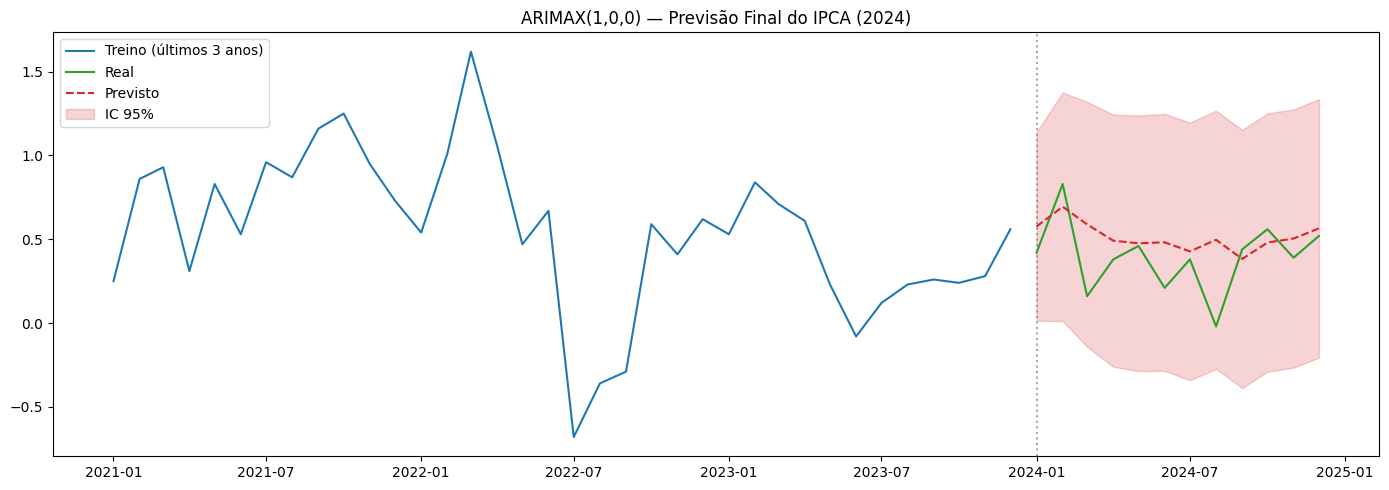

          Real  Previsto    Erro
data                            
Jan/2024  0.42    0.5762 -0.1562
Feb/2024  0.83    0.6943  0.1357
Mar/2024  0.16    0.5890 -0.4290
Apr/2024  0.38    0.4916 -0.1116
May/2024  0.46    0.4760 -0.0160
Jun/2024  0.21    0.4818 -0.2718
Jul/2024  0.38    0.4278 -0.0478
Aug/2024 -0.02    0.4969 -0.5169
Sep/2024  0.44    0.3826  0.0574
Oct/2024  0.56    0.4807  0.0793
Nov/2024  0.39    0.5046 -0.1146
Dec/2024  0.52    0.5648 -0.0448


In [27]:
# Gráfico final com intervalo de confiança
forecast_obj = results_final.get_forecast(steps=12, exog=test[exog_cols_final])
forecast_mean = forecast_obj.predicted_mean
forecast_ci   = forecast_obj.conf_int(alpha=0.05)

plt.figure(figsize=(14, 5))
plt.plot(train['ipca'].iloc[-36:], label='Treino (últimos 3 anos)', color='tab:blue')
plt.plot(test['ipca'],             label='Real',                    color='tab:green')
plt.plot(forecast_mean,            label='Previsto',                color='tab:red', linestyle='--')
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1],
                 alpha=0.2, color='tab:red', label='IC 95%')
plt.axvline(test.index[0], color='gray', linestyle=':', alpha=0.7)
plt.legend()
plt.title('ARIMAX(1,0,0) — Previsão Final do IPCA (2024)')
plt.tight_layout()
plt.show()

# Tabela de resultados mês a mês
results_table = pd.DataFrame({
    'Real':     test['ipca'].values,
    'Previsto': forecast_mean.values,
    'Erro':     (test['ipca'].values - forecast_mean.values)
}, index=test.index.strftime('%b/%Y'))

print(results_table.round(4))